In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Transient Detection in Strong Lenses with SBI

Amortized posterior on `transient_flux_frac` using `sbi.NPE` with a CNN embedding net.

- **Training data:** 10K paired clean / anomalous lens images from `data/`.
- **Parameter:** `theta = transient_flux_frac`, with `0` for clean images and the metadata value for anomalous ones.
- **Detection rule:** posterior mass above a small threshold given an observed image.
- **Bonus:** when a transient is detected, the same posterior also estimates its flux.

In [3]:
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
!pip install sbi
from sbi.inference import NPE
from sbi.neural_nets import posterior_nn
from sbi.utils import BoxUniform

DATA_DIR = Path('/content/drive/MyDrive/sbi-data')
ARTIFACT_DIR = Path('artifacts')
ARTIFACT_DIR.mkdir(exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
SEED = 0
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'device = {DEVICE}')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.8/45.8 kB 5.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 517.8/517.8 kB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 756.0/756.0 kB 63.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.0/48.0 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.5/268.5 kB 28.0 MB/s eta 0:00:00
  Created wheel for nflows: filename=nflows-0.14-py3-none-any.whl size=53654 sha256=6ea3bdcda83808cac3ee8b0e75291ec7c496ee6bb54f18dc0e9e06adb67acce8
  Stored in directory: /root/.cache/pip/wheels/fd/27/c3/8952205ea17b63dc1eaa24031e63111c6a3661cb22cc1e2a3c
Successfully built nflows
device = cuda


## 1. Load data and build (theta, x) tensors

Each underlying lens system contributes two rows: one clean (theta=0) and one anomalous (theta=metadata flux frac). We split by **lens index** so the paired halves never straddle train/test.

In [4]:
clean = np.load(DATA_DIR / 'clean_images.npy')         # (N, 240, 240)
anom  = np.load(DATA_DIR / 'anomalous_images.npy')      # (N, 240, 240)
with open(DATA_DIR / 'metadata.pkl', 'rb') as f:
    metadata = pickle.load(f)

N = clean.shape[0]
assert anom.shape[0] == N == len(metadata)
flux_frac = np.array([m['transient_flux_frac'] for m in metadata], dtype=np.float32)
print(f'N = {N}, image shape = {clean.shape[1:]}, flux_frac range = [{flux_frac.min():.3f}, {flux_frac.max():.3f}]')

N = 10000, image shape = (240, 240), flux_frac range = [0.050, 0.150]


In [5]:
# Split by lens index so paired clean+anomalous of the same system stay together.
rng = np.random.default_rng(SEED)
perm = rng.permutation(N)
n_train = int(0.8 * N)
n_val   = int(0.1 * N)
train_idx = perm[:n_train]
val_idx   = perm[n_train:n_train + n_val]
test_idx  = perm[n_train + n_val:]
print(f'train/val/test lens systems: {len(train_idx)}/{len(val_idx)}/{len(test_idx)}')

train/val/test lens systems: 8000/1000/1000


In [6]:
def arcsinh_normalize(images):
    """Match the visualization stretch in simulator.ipynb, then per-image standardize."""
    x = np.arcsinh(images / 0.05).astype(np.float32)
    mean = x.mean(axis=(1, 2), keepdims=True)
    std  = x.std(axis=(1, 2), keepdims=True) + 1e-6
    return (x - mean) / std

def build_split(idx):
    """Stack clean (theta=0) and anomalous (theta=flux_frac) for a list of lens indices."""
    x_clean = arcsinh_normalize(clean[idx])
    x_anom  = arcsinh_normalize(anom[idx])
    x = np.concatenate([x_clean, x_anom], axis=0)[:, None]  # (2*len(idx), 1, 240, 240)
    theta = np.concatenate([np.zeros(len(idx), dtype=np.float32), flux_frac[idx]])[:, None]
    return torch.from_numpy(theta), torch.from_numpy(x)

theta_train, x_train = build_split(train_idx)
theta_val,   x_val   = build_split(val_idx)
theta_test,  x_test  = build_split(test_idx)
print(f'x_train {tuple(x_train.shape)}, theta_train {tuple(theta_train.shape)}')

x_train (16000, 1, 240, 240), theta_train (16000, 1)


## 2. CNN embedding network

Maps the 240x240 image to a 64-D summary that `sbi` then feeds into the density estimator.

In [7]:
class ConvBlock(nn.Module):
    def __init__(self, c_in, c_out):
        super().__init__()
        self.conv1 = nn.Conv2d(c_in, c_out, 3, padding=1)
        self.conv2 = nn.Conv2d(c_out, c_out, 3, padding=1)
        self.norm1 = nn.GroupNorm(8, c_out)
        self.norm2 = nn.GroupNorm(8, c_out)
        self.pool = nn.AvgPool2d(2)
    def forward(self, x):
        x = F.gelu(self.norm1(self.conv1(x)))
        x = F.gelu(self.norm2(self.conv2(x)))
        return self.pool(x)

class LensEmbedding(nn.Module):
    """240 -> 120 -> 60 -> 30 -> 15 -> GAP -> 64"""
    def __init__(self, out_dim=64):
        super().__init__()
        self.blocks = nn.Sequential(
            ConvBlock(1, 16),
            ConvBlock(16, 32),
            ConvBlock(32, 64),
            ConvBlock(64, 128),
        )
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Flatten(),
            nn.Linear(128, out_dim),
        )
    def forward(self, x):
        if x.dim() == 3:
            x = x.unsqueeze(1)  # sbi sometimes passes (B, H, W)
        return self.head(self.blocks(x))

embedding_net = LensEmbedding(out_dim=64)
n_params = sum(p.numel() for p in embedding_net.parameters())
print(f'embedding net params: {n_params/1e6:.2f} M')

embedding net params: 0.30 M


## 3. Train NPE

Prior is `BoxUniform(0, 0.15)` so theta=0 is included. The training set already provides matched theta=0 examples (clean images), so the model learns a sharp mode there for non-transient inputs.

In [9]:
import time
import warnings

# Silence two harmless sbi warnings:
#   1. per-pixel "extreme outliers" check — sbi runs this regardless of z_score_x.
#   2. device-string normalization (mps:0 -> mps).
warnings.filterwarnings('ignore', message='Data has extreme outliers')
warnings.filterwarnings('ignore', message=".*has device 'mps:0'.*")

prior = BoxUniform(low=torch.tensor([0.0]), high=torch.tensor([0.15]), device=DEVICE)

# z_score_x='none' is critical: we already arcsinh+standardize images in
# arcsinh_normalize(), and sbi's default per-pixel z-scoring would (a) flag
# every bright arc pixel as an outlier and (b) break the spatial structure
# the CNN embedding net relies on.
density_estimator_build = posterior_nn(
    model='nsf',
    embedding_net=embedding_net,
    hidden_features=64,
    num_transforms=5,
    z_score_x='none',
)

inference = NPE(
    prior=prior,
    density_estimator=density_estimator_build,
    device=DEVICE,
    show_progress_bars=False,
)
# Keep the full training set on CPU — sbi streams batches to the GPU itself.
# Pre-moving x_train to CUDA OOMs because append_simulations runs
# torch.quantile(x, dim=0) on the entire (16000, 1, 240, 240) tensor for its
# outlier check, which allocates several full-size scratch copies (~10 GB).
inference = inference.append_simulations(theta_train, x_train, data_device='cpu')

# sbi's built-in progress only prints "Epochs trained: N" — no losses. Patch
# the per-epoch summary hook so we get a live train/val loss line each epoch.
_orig_summarize = inference._summarize_epoch
_t0 = time.time()

def _summarize_and_print(train_loss, val_loss, epoch_start_time, summarization_kwargs):
    _orig_summarize(train_loss, val_loss, epoch_start_time, summarization_kwargs)
    epoch = inference.epoch + 1   # sbi increments self.epoch *after* this call
    best  = inference._best_val_loss
    marker = '  *' if val_loss <= best else ''
    print(
        f'epoch {epoch:3d} | train_loss={train_loss:+.4f} | '
        f'val_loss={val_loss:+.4f} | best={best:+.4f} | '
        f'{time.time() - _t0:6.1f}s{marker}',
        flush=True,
    )

inference._summarize_epoch = _summarize_and_print

density_estimator = inference.train(
    training_batch_size=128,
    learning_rate=5e-4,
    validation_fraction=0.1,
    stop_after_epochs=15,
    max_num_epochs=200,
    show_train_summary=True,
)
posterior = inference.build_posterior(density_estimator)

epoch   1 | train_loss=-2.8446 | val_loss=-3.9779 | best=+inf |   20.1s  *
epoch   2 | train_loss=-2.8689 | val_loss=-3.7662 | best=-3.9779 |   32.0s
epoch   3 | train_loss=-3.3784 | val_loss=-4.1598 | best=-3.9779 |   43.8s  *
epoch   4 | train_loss=-3.5087 | val_loss=-4.1173 | best=-4.1598 |   55.7s
epoch   5 | train_loss=-3.9624 | val_loss=-4.3581 | best=-4.1598 |   67.6s  *
epoch   6 | train_loss=-3.6622 | val_loss=-4.2894 | best=-4.3581 |   79.7s
epoch   7 | train_loss=-3.7362 | val_loss=-3.2501 | best=-4.3581 |   91.6s
epoch   8 | train_loss=-3.8107 | val_loss=-4.3203 | best=-4.3581 |  103.4s
epoch   9 | train_loss=-3.8779 | val_loss=-4.1789 | best=-4.3581 |  115.3s
epoch  10 | train_loss=-3.9459 | val_loss=-4.0821 | best=-4.3581 |  127.2s
epoch  11 | train_loss=-4.0189 | val_loss=-3.8624 | best=-4.3581 |  139.1s
epoch  12 | train_loss=-4.0374 | val_loss=-4.0008 | best=-4.3581 |  151.0s
epoch  13 | train_loss=-4.0420 | val_loss=-4.7103 | best=-4.3581 |  163.0s  *
epoch  14 | trai

In [10]:
# Persist artifacts so the rest of the notebook can be re-run without retraining.
torch.save(density_estimator.state_dict(), ARTIFACT_DIR / 'density_estimator.pt')
torch.save({'theta_test': theta_test, 'x_test': x_test, 'test_idx': test_idx},
           ARTIFACT_DIR / 'test_split.pt')
print('saved artifacts to', ARTIFACT_DIR)

saved artifacts to artifacts


## 4. Evaluate on the held-out test set

For each test image, draw posterior samples and compute the detection score `P(theta > eps | x)`.

In [11]:
EPS = 0.01      # transient flux threshold
N_SAMPLES = 500

def detection_scores(x_batch):
    scores = np.zeros(len(x_batch), dtype=np.float32)
    medians = np.zeros(len(x_batch), dtype=np.float32)
    for i in range(len(x_batch)):
        x_i = x_batch[i].to(DEVICE)
        samples = posterior.sample((N_SAMPLES,), x=x_i, show_progress_bars=False)
        s = samples.detach().cpu().numpy().ravel()
        scores[i]  = float((s > EPS).mean())
        medians[i] = float(np.median(s))
    return scores, medians

scores, medians = detection_scores(x_test)
labels = (theta_test.numpy().ravel() > 0).astype(np.int32)
print(f'mean score (clean) = {scores[labels==0].mean():.3f}')
print(f'mean score (anom)  = {scores[labels==1].mean():.3f}')

mean score (clean) = 0.698
mean score (anom)  = 0.698


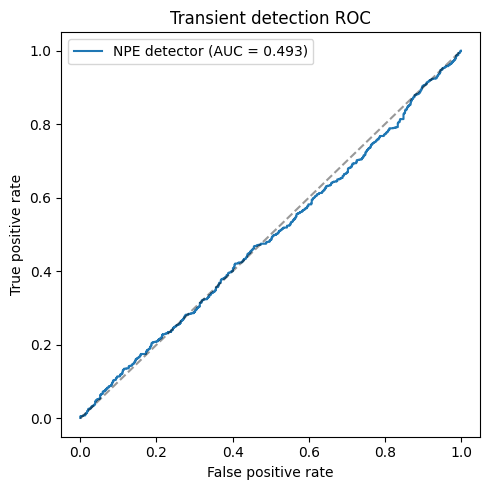

In [12]:
# ROC curve (no sklearn dependency).
def roc_curve(y_true, y_score):
    order = np.argsort(-y_score)
    y_true = y_true[order]
    tps = np.cumsum(y_true)
    fps = np.cumsum(1 - y_true)
    tpr = tps / max(y_true.sum(), 1)
    fpr = fps / max((1 - y_true).sum(), 1)
    auc = float(np.trapezoid(tpr, fpr))
    return fpr, tpr, auc

fpr, tpr, auc = roc_curve(labels, scores)
plt.figure(figsize=(5, 5))
plt.plot(fpr, tpr, label=f'NPE detector (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', alpha=0.4)
plt.xlabel('False positive rate')
plt.ylabel('True positive rate')
plt.title('Transient detection ROC')
plt.legend()
plt.tight_layout()
plt.show()

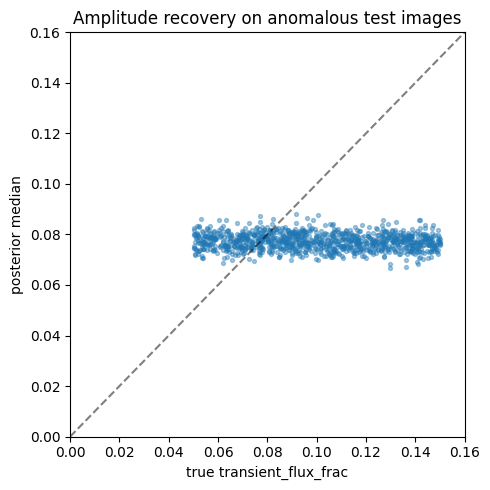

In [13]:
# Amplitude recovery: posterior median vs true flux frac for the anomalous half.
true_anom = theta_test.numpy().ravel()[labels == 1]
pred_anom = medians[labels == 1]

plt.figure(figsize=(5, 5))
plt.scatter(true_anom, pred_anom, s=8, alpha=0.4)
lim = [0, 0.16]
plt.plot(lim, lim, 'k--', alpha=0.5)
plt.xlim(lim); plt.ylim(lim)
plt.xlabel('true transient_flux_frac')
plt.ylabel('posterior median')
plt.title('Amplitude recovery on anomalous test images')
plt.tight_layout()
plt.show()

## 5. Calibration on the with-transient subset

Simulation-based calibration: for each anomalous test image, look at the rank of the true theta inside posterior samples. A trustworthy posterior gives a flat rank histogram.

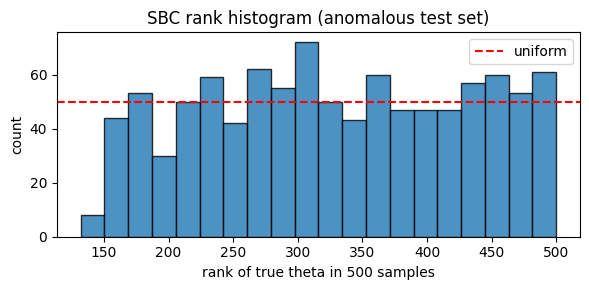

In [14]:
anom_x = x_test[labels == 1]
anom_theta = theta_test[labels == 1].numpy().ravel()

ranks = np.zeros(len(anom_x), dtype=np.int32)
for i in range(len(anom_x)):
    x_i = anom_x[i].to(DEVICE)
    samples = posterior.sample((N_SAMPLES,), x=x_i, show_progress_bars=False)
    s = samples.detach().cpu().numpy().ravel()
    ranks[i] = int((s < anom_theta[i]).sum())

plt.figure(figsize=(6, 3))
plt.hist(ranks, bins=20, edgecolor='k', alpha=0.8)
plt.axhline(len(anom_x) / 20, color='r', linestyle='--', label='uniform')
plt.xlabel(f'rank of true theta in {N_SAMPLES} samples')
plt.ylabel('count')
plt.title('SBC rank histogram (anomalous test set)')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Failure mode inspection

Look at the worst 5 false positives and 5 false negatives at a 0.5 score cutoff.

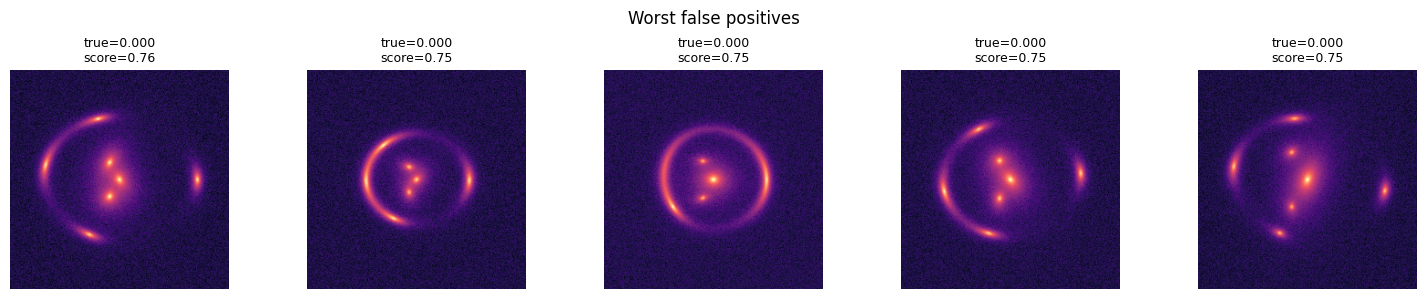

In [15]:
def show_examples(image_indices, title):
    fig, axes = plt.subplots(1, len(image_indices), figsize=(3 * len(image_indices), 3))
    for ax, i in zip(np.atleast_1d(axes), image_indices):
        ax.imshow(x_test[i, 0].numpy(), origin='lower', cmap='magma')
        ax.set_title(f'true={theta_test[i].item():.3f}\nscore={scores[i]:.2f}', fontsize=9)
        ax.axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

fp_idx = np.where((labels == 0) & (scores > 0.5))[0]
fn_idx = np.where((labels == 1) & (scores < 0.5))[0]
fp_idx = fp_idx[np.argsort(-scores[fp_idx])][:5]
fn_idx = fn_idx[np.argsort(scores[fn_idx])][:5]
if len(fp_idx):
    show_examples(fp_idx, 'Worst false positives')
if len(fn_idx):
    show_examples(fn_idx, 'Worst false negatives')